In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

train = pd.read_csv('train.csv')
train['dt'] = pd.to_datetime(train['dt'])
train.set_index('dt', inplace=True)

for lag in [1, 2, 3, 4]:
    train[f"close_lag_{lag}"] = train["close"].shift(lag)

train["returns"] = train["close"] / train["close"].shift(1)
train["Range"] = train["high"] - train["low"]
train["volatility_5"] = train["close"].rolling(5).std() 
train["SMA_5"] = train["close"].rolling(5).mean() 

## ATR
#train['TR'] = np.maximum(
#    train['high'] - train['low'],
#    np.maximum(
#        abs(train['high'] - train['close'].shift(1)),
#        abs(train['low'] - train['close'].shift(1))
#))
#train['ATR_5'] = train['TR'].rolling(5).mean()
#
## RSI
#delta = train['close'].diff()
#gain = delta.where(delta > 0, 0)
#loss = -delta.where(delta < 0, 0)
#avg_gain = gain.rolling(5).mean()
#avg_loss = loss.rolling(5).mean()
#rs = avg_gain / avg_loss
#train['RSI_5'] = 100 - (100 / (1 + rs))
#
## Перекрестные признаки
#train['Close_vs_SMA5'] = train['close'] / train['SMA_5']
#train['Range_vs_ATR5'] = train['Range'] / train['ATR_5']

# Удаляем NaN
train.dropna(inplace=True)
#train.drop(columns=['TR'], inplace=True)

In [ ]:
def prepare_direct_forecasting_data(data, horizon=13):
    X, y = [], []
    
    for i in range(len(data) - horizon):
        features = data.iloc[i].drop('close').values
        
        targets = data['close'].iloc[i+1:i+horizon+1].values
        
        X.append(features)
        y.append(targets)
    
    return np.array(X), np.array(y)

X, y = prepare_direct_forecasting_data(train, horizon=13)
print(f"Форма X: {X.shape}, Форма y: {y.shape}")

Форма X: (62, 10), Форма y: (62, 13)


In [17]:
print(y)

[[0.7290136  0.80560673 0.8362441  0.80560673 0.84773319 0.80637283
  0.8507964  0.8515625  0.8446694  0.8507964  0.86305158 0.90441195
  0.93964472]
 [0.80560673 0.8362441  0.80560673 0.84773319 0.80637283 0.8507964
  0.8515625  0.8446694  0.8507964  0.86305158 0.90441195 0.93964472
  0.9741114 ]
 [0.8362441  0.80560673 0.84773319 0.80637283 0.8507964  0.8515625
  0.8446694  0.8507964  0.86305158 0.90441195 0.93964472 0.9741114
  0.97028209]
 [0.80560673 0.84773319 0.80637283 0.8507964  0.8515625  0.8446694
  0.8507964  0.86305158 0.90441195 0.93964472 0.9741114  0.97028209
  0.94730392]
 [0.84773319 0.80637283 0.8507964  0.8515625  0.8446694  0.8507964
  0.86305158 0.90441195 0.93964472 0.9741114  0.97028209 0.94730392
  0.99708957]
 [0.80637283 0.8507964  0.8515625  0.8446694  0.8507964  0.86305158
  0.90441195 0.93964472 0.9741114  0.97028209 0.94730392 0.99708957
  1.01623785]
 [0.8507964  0.8515625  0.8446694  0.8507964  0.86305158 0.90441195
  0.93964472 0.9741114  0.97028209 0.

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [ ]:
model = Ridge(alpha=0.01)

model.fit(X_train_scaled, y_train)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled) 

mae_per_step = mean_absolute_error(y_val, y_pred, multioutput='raw_values')
rmse_per_step = np.sqrt(((y_val - y_pred) ** 2).mean(axis=0))

print("MAE по шагам прогноза:")
for step, mae in enumerate(mae_per_step, 1):
    print(f"День {step}: {mae:.6f}")

print(f"\nСредний MAE: {mae_per_step.mean():.6f}")

MAE по шагам прогноза:
День 1: 0.101819
День 2: 0.112556
День 3: 0.137764
День 4: 0.166847
День 5: 0.205515
День 6: 0.262238
День 7: 0.313745
День 8: 0.363675
День 9: 0.417968
День 10: 0.476323
День 11: 0.511494
День 12: 0.496656
День 13: 0.478773

Средний MAE: 0.311183


In [ ]:
# Убрала последние 13 дней из данных, которые нам были даны, 
# чтобы можно было сразу проверить как меняется ошибка без загрузки данных на сайт kaggle

y_test_pred = [ 3.3638175335937914,
3.555300369122203,
3.524662998565809,
3.524662998565809,
3.5591296752172283,
3.5935969362278852,
3.6204044163300146,
3.8386947319605547,
3.8118872518584253,
4.014859174390389,
4.060814938045358,
4.041666654492517,
3.8961395826190772]

In [ ]:
def forecast_13_days(model, scaler, last_known_data):

    features = last_known_data.drop('close').values.reshape(1, -1)
    features_scaled = scaler.transform(features)

    predictions = model.predict(features_scaled)[0]
    
    return predictions

last_known_point = train.iloc[-1]

future_predictions = forecast_13_days(model, scaler, last_known_point)

last_date = train.index[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=13)

In [22]:
train

,high,low,close,close_lag_1,close_lag_2,close_lag_3,close_lag_4,returns,Range,volatility_5,SMA_5
dt,,,,,,,,,,,
2023-07-08,0.901348,0.721354,0.843903,0.698376,0.634038,0.768076,0.859222,1.208379,0.179994,0.095670,0.760723
2023-07-09,1.072151,0.679994,0.729014,0.843903,0.698376,0.634038,0.768076,0.863859,0.392157,0.078301,0.734681
2023-07-10,0.836244,0.767310,0.805607,0.729014,0.843903,0.698376,0.634038,1.105064,0.068934,0.083901,0.742188
2023-07-11,0.843903,0.813266,0.836244,0.805607,0.729014,0.843903,0.698376,1.038030,0.030637,0.065441,0.782629
2023-07-12,0.862285,0.791820,0.805607,0.836244,0.805607,0.729014,0.843903,0.963363,0.070466,0.045442,0.804075
...,...,...,...,...,...,...,...,...,...,...,...
2023-10-17,2.988511,2.950214,2.988511,2.989277,2.988511,3.044424,3.026808,0.999744,0.038297,0.026407,3.007506
2023-10-18,3.033701,2.919577,2.957491,2.988511,2.989277,2.988511,3.044424,0.989620,0.114124,0.031454,2.993643
2023-10-21,3.217524,2.991575,3.064338,2.957491,2.988511,2.989277,2.988511,1.036128,0.225950,0.039677,2.997626


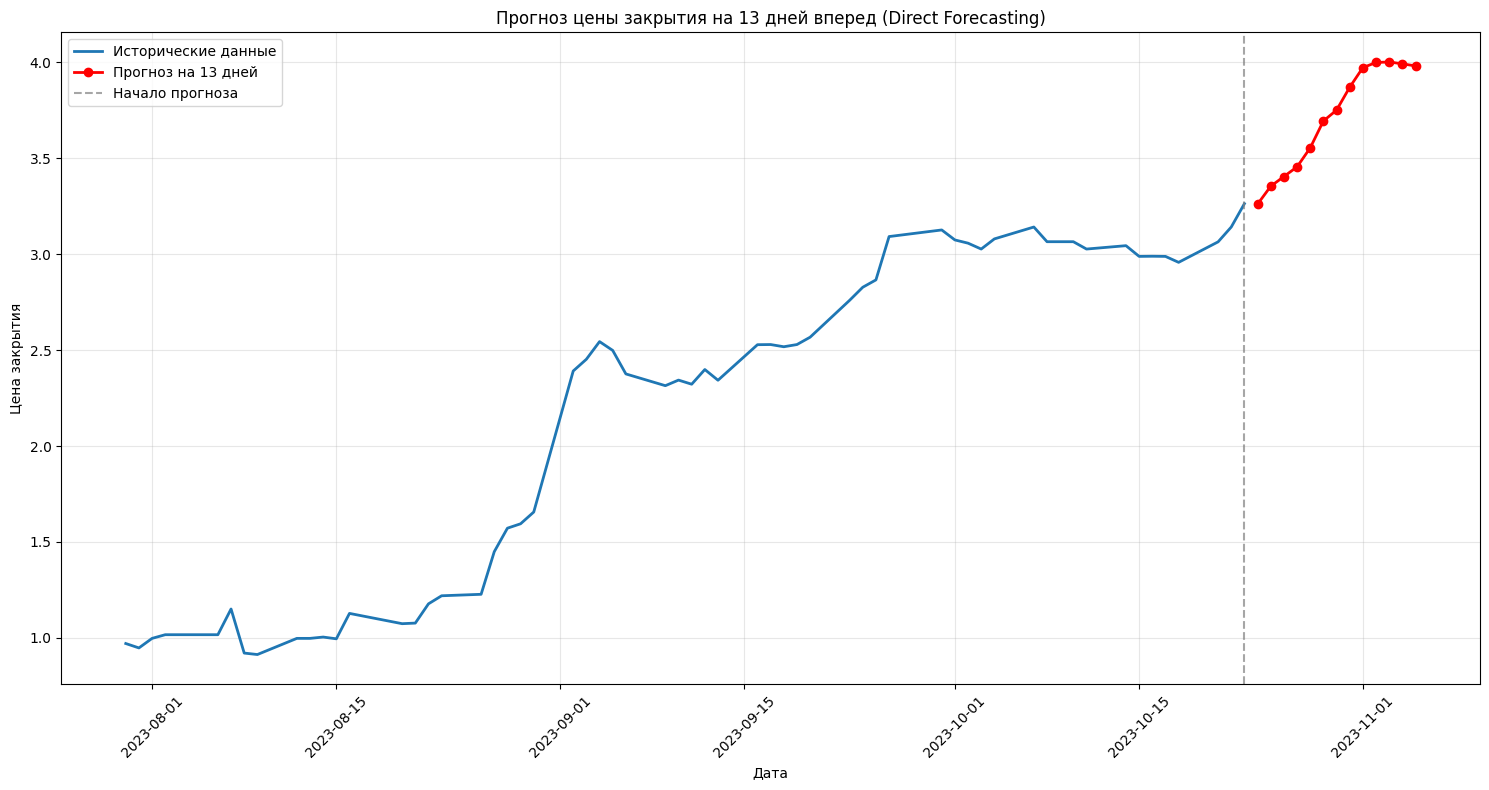


ПРОГНОЗ НА 13 ДНЕЙ ВПЕРЕД
День  1 (2023-10-24): 3.260971
День  2 (2023-10-25): 3.354268
День  3 (2023-10-26): 3.404881
День  4 (2023-10-27): 3.455331
День  5 (2023-10-28): 3.554312
День  6 (2023-10-29): 3.694431
День  7 (2023-10-30): 3.750957
День  8 (2023-10-31): 3.870393
День  9 (2023-11-01): 3.972734
День 10 (2023-11-02): 3.999408
День 11 (2023-11-03): 4.002172
День 12 (2023-11-04): 3.992410
День 13 (2023-11-05): 3.981530


In [ ]:
plt.figure(figsize=(15, 8))

historical_dates = train.index[-60:]
historical_prices = train['close'][-60:]

plt.plot(historical_dates, historical_prices, label='Исторические данные', linewidth=2)

plt.plot(future_dates, future_predictions, label='Прогноз на 13 дней', 
         marker='o', linewidth=2, color='red')

plt.axvline(x=last_date, color='gray', linestyle='--', alpha=0.7, label='Начало прогноза')
plt.title('Прогноз цены закрытия на 13 дней вперед (Direct Forecasting)')
plt.xlabel('Дата')
plt.ylabel('Цена закрытия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ПРОГНОЗ НА 13 ДНЕЙ ВПЕРЕД")
print("="*50)
for i, (date, price) in enumerate(zip(future_dates, future_predictions), 1):
    print(f"День {i:2d} ({date.strftime('%Y-%m-%d')}): {price:.6f}")

In [24]:
mae_1 = mean_absolute_error(y_test_pred, future_predictions)
mae_1

0.08696022626906051